# Integrating a patient cohort with scDEF

Five patients, one shared biology, five different batches. The task is the one every cohort study
faces: pull out the cell states that are **shared across patients** without mistaking a batch effect
for biology, or erasing real patient-specific signal while correcting for one.

This runs the real **[scDEF](https://github.com/cbg-ethz/scDEF)** (Ferreira et al.) — a hierarchical
Bayesian factor model — **in this notebook's own kernel** (`Python (iscc-scdef)`), so its own
plotting works and the model object is right here to inspect.

It loads a pre-generated cohort; see
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb) for how it was made and what
is held back:

| file | what it is | who sees it |
|---|---|---|
| `counts.csv.gz` | cells × genes, five patients pooled | the tool |
| `obs.csv` | each cell's patient and batch | the tool (batch only) |
| `truth_loading.csv.gz` | the shared program dictionary iscc planted | **scoring only** |
| `truth_activity.csv.gz` | each cell's true program activities | **scoring only** |

**What makes this measurable.** Every patient draws from the *same* program dictionary while its
tumour evolves privately — its own clones, its own copy-number landscape. So a shared program is
genuinely shared, and we know exactly which genes it spans.

In [1]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scdef
from scdef import plotting as sdp
from scdef import tools as sdt

DATA = os.path.join("..", "analysis_data", "cohort")
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only cohort")

X   = pd.read_csv(os.path.join(DATA, "counts.csv.gz"), index_col=0)
obs = pd.read_csv(os.path.join(DATA, "obs.csv"), index_col=0)
meta = json.load(open(os.path.join(DATA, "meta.json")))

adata = ad.AnnData(X.values.astype("float32"))
adata.obs_names = list(X.index); adata.var_names = list(X.columns)
adata.obs["patient"] = pd.Categorical(obs.loc[X.index, "patient"])
adata.obs["batch"]   = pd.Categorical(obs.loc[X.index, "batch"])
adata.layers["counts"] = adata.X.copy()

print(f"cohort: {meta['n_patients']} patients, {meta['n_cells']:,} cells, "
      f"{meta['n_genes']} genes, {meta['n_programs']} planted programs")
print("cells per patient:", adata.obs['patient'].value_counts().to_dict())
print(f"scDEF {scdef.__version__} running in-process (kernel: Python (iscc-scdef))")

/Users/pedroferreira/miniconda3/envs/iscc-scdef/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cohort: 5 patients, 1,500 cells, 400 genes, 6 planted programs
cells per patient: {'P0': 300, 'P1': 300, 'P2': 300, 'P3': 300, 'P4': 300}
scDEF 0.6.1 running in-process (kernel: Python (iscc-scdef))


## Fit

scDEF is given the batch label and does its own correction — the honest way to test it, rather than
pre-correcting the counts by hand and handing it something already cleaned.

In [2]:
# n_factors above the 6 planted programs, so scDEF has room to invent a spurious one if the data
# invites it — giving it exactly as many factors as there are programs would hide that.
sd = scdef.scDEF(adata, counts_layer="counts", n_factors=meta["n_programs"] + 2,
                 batch_key="batch", seed=1)
sd.fit(n_epoch=300)
print("layer sizes (finest -> coarsest):", sd.layer_sizes)

INFO:scDEF:Found 5 values for `batch` in data: ['batch0' 'batch1' 'batch2' 'batch3' 'batch4']


INFO:scDEF:Each epoch contains 6 batches of size 256



INFO:scDEF:Stopping learning: reached max epochs (n_epoch=300).


INFO:scDEF:Updated adata.var: `gene_scale_0` for batch 0.


INFO:scDEF:Updated adata.var: `gene_scale_1` for batch 1.


...

INFO:scDEF:Updated adata.uns with layer 4 signatures: `L4_signatures`.


INFO:scDEF:Updated adata.obs with layer 5: `L5` and `L5_score` for all factors in layer 5


INFO:scDEF:Updated adata.obsm with layer 5: `X_L5`


INFO:scDEF:Updated adata.uns with layer 5 signatures: `L5_signatures`.


layer sizes (finest -> coarsest): [8, 5, 3, 2, 1, 1]


## Did it fit? — `scdef.pl.qc`

scDEF ships its own diagnostic panel: the ELBO trace, the biological relevance determination that
decides how many factors survive, and the learned-vs-observed cell and gene scales. This is the
figure to read before trusting anything downstream.

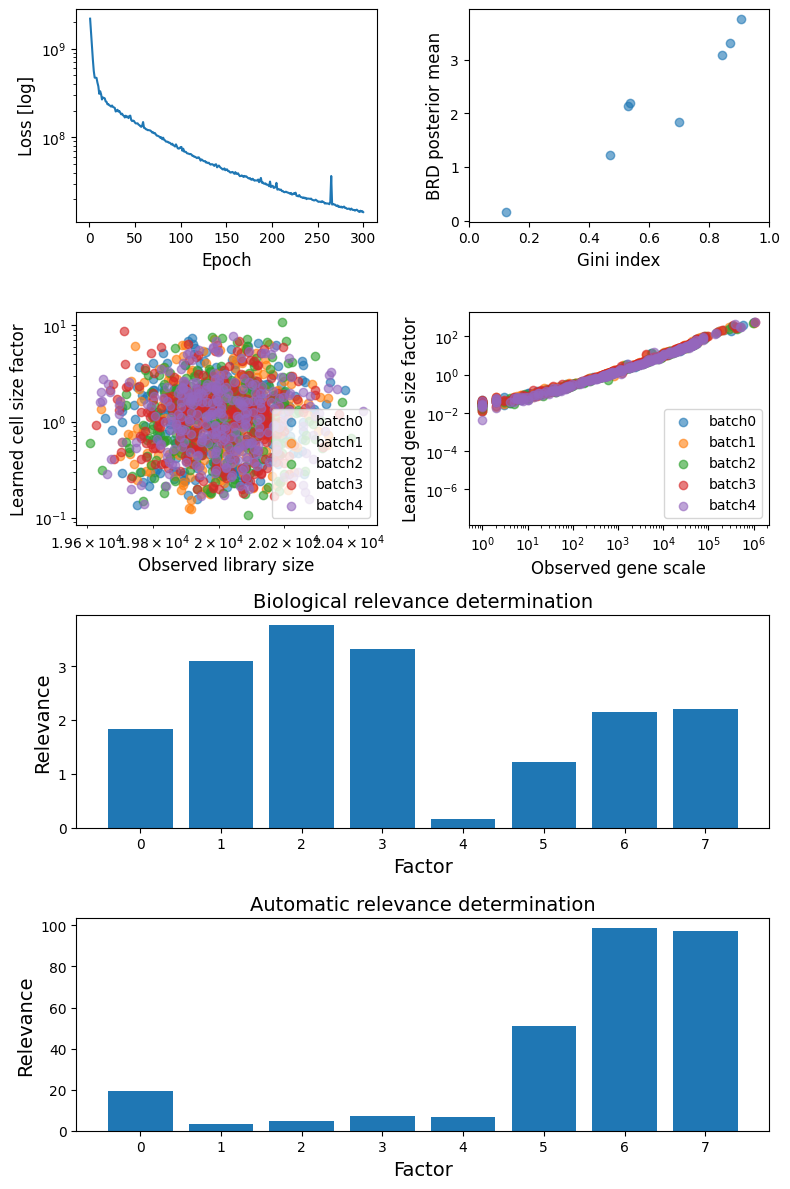

In [3]:
sdp.qc(sd)

## The factor hierarchy — `scdef.pl.make_graph`

scDEF does not infer a flat set of factors: it infers a **hierarchy**, broad factors at the top
splitting into finer ones below. That graph is its signature output and the thing it offers over a
flat factor model, so it is what a user would look at first.

`fit()` builds the graph, but the drawing is done from the model's *confident signatures*, which are
a separate post-fit step (`scdef.tl.set_confident_signatures`) — calling `make_graph` without it
raises a `KeyError` telling you exactly that.

INFO:scDEF:Updated scDEF graph


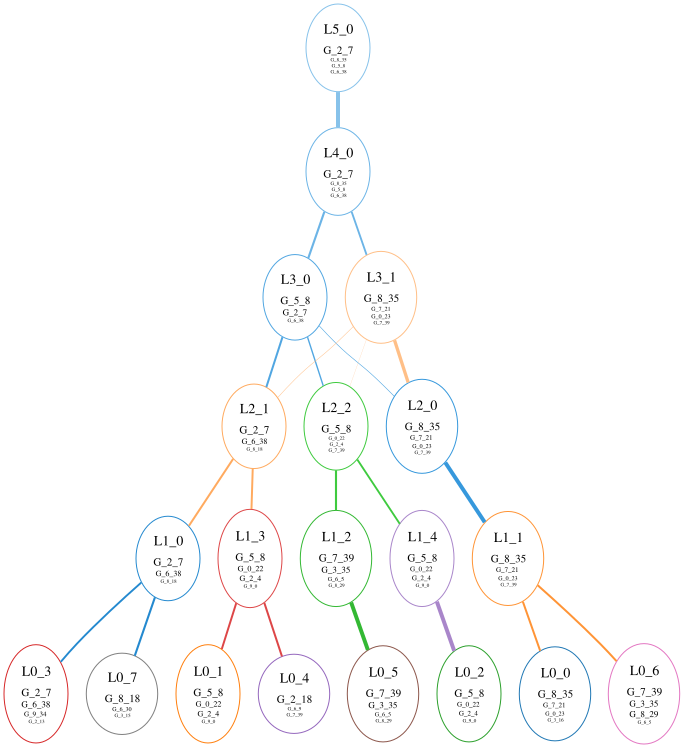

In [4]:
sdt.set_confident_signatures(sd)
sdp.make_graph(sd, show_all=False)

## Do the patients mix? — `scdef.pl.umap`

The failure mode of any cohort integration is one factor per patient: batch masquerading as biology.
scDEF embeds **each layer** of its hierarchy separately, so this is checkable layer by layer. Coloured
by patient and by batch, cells drawn from a shared program should sit together regardless of which
patient they came from.

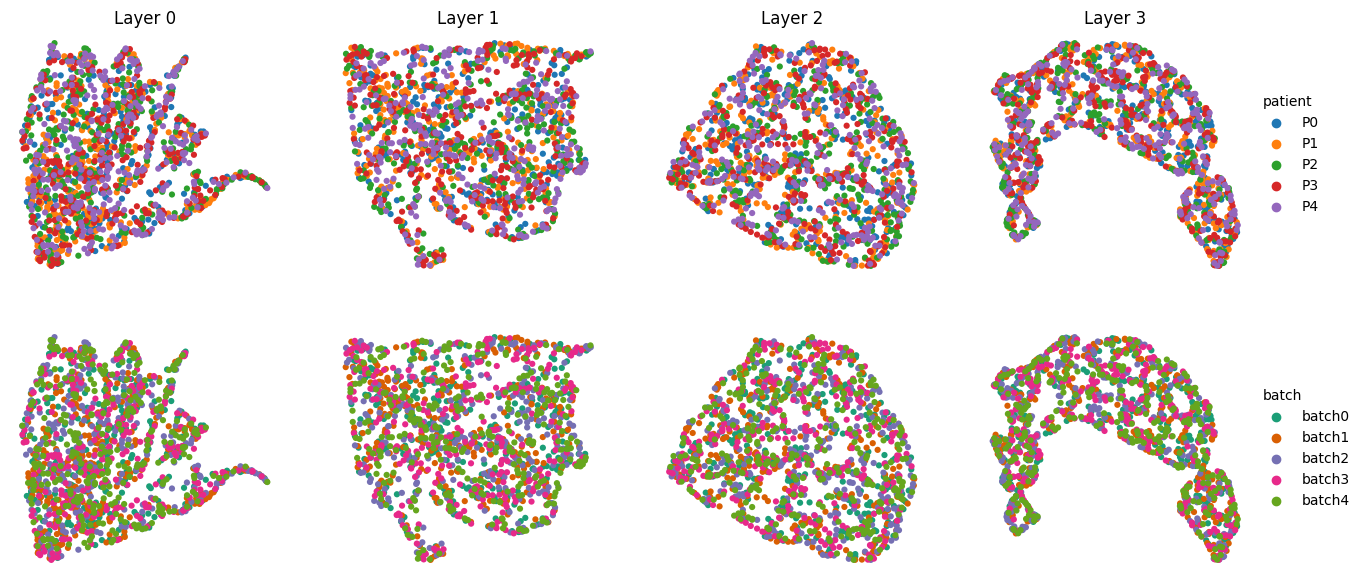

In [5]:
sdt.umap(sd)
sdp.umap(sd, color=["patient", "batch"], figsize=(16, 7))

## Which factors does each patient use? — `scdef.pl.obs_scores`

The same question, quantified. `obs_scores` plots the association between an `obs` annotation and the
factors of every layer. A **shared** program is used by all five patients (a full column); a factor
confined to a single row is patient-specific — or that patient's batch.

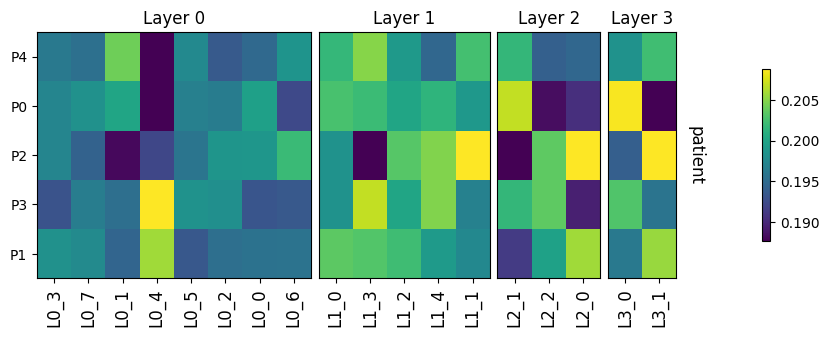

In [6]:
sdp.obs_scores(sd, ["patient"], mode="fracs", figsize=(11, 3.2))

## Scoring against the planted dictionary

Now the truth, which the model has not seen. Each planted program is Hungarian-matched to its best
inferred factor by cosine over the gene loadings — the same scoring `validate_programs` applies to
this model.

In [7]:
from scipy.optimize import linear_sum_assignment

true_loading = pd.read_csv(os.path.join(DATA, "truth_loading.csv.gz"), index_col=0)
true_loading = true_loading[adata.var_names].values          # align genes to the fitted matrix

# L0W is the FINEST layer's gene loadings (factors x genes) — the matrix comparable to the planted
# dictionary. L0z holds the per-cell activities, and L1W the hierarchy above it.
W = np.asarray(sd.pmeans["L0W"])

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

K = true_loading.shape[0]
C = np.array([[cosine(true_loading[i], W[j]) for j in range(W.shape[0])] for i in range(K)])
rows, cols = linear_sum_assignment(-C)
matched = C[rows, cols]

print("shared-program recovery (cosine to the planted dictionary):")
for i, j in zip(rows, cols):
    print(f"  program{i}  ->  factor {j:<3} cosine {C[i, j]:.2f}")
print(f"\n  mean matched cosine: {matched.mean():.2f}")

shared-program recovery (cosine to the planted dictionary):
  program0  ->  factor 3   cosine 0.82
  program1  ->  factor 5   cosine 0.37
  program2  ->  factor 7   cosine 0.08
  program3  ->  factor 0   cosine 0.71
  program4  ->  factor 4   cosine 0.22
  program5  ->  factor 1   cosine 0.79

  mean matched cosine: 0.50


### The planted programs, factor by factor — `scdef.pl.continuous_obs_scores`

The cosines above compare *gene loadings*. The complementary view is per **cell**: iscc recorded how
active each planted program was in every cell, so attaching those as continuous annotations lets
scDEF's own `continuous_obs_scores` correlate each planted program against every factor in every
layer.

These columns are attached **after** the fit — they are the answer key, never an input.

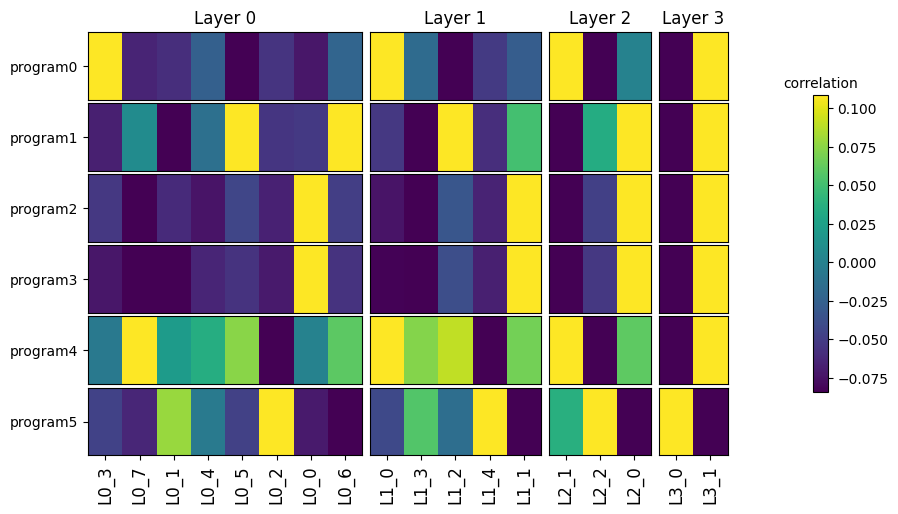

In [8]:
activity = pd.read_csv(os.path.join(DATA, "truth_activity.csv.gz"), index_col=0)
programs = [str(c) for c in activity.columns]
for p in programs:
    sd.adata.obs[p] = activity.loc[sd.adata.obs_names, p].astype(float).values

sdp.continuous_obs_scores(sd, programs, figsize=(11, 5.5), cb_title="correlation")

## What to take from it

A cohort integration is only useful if the shared biology survives it. Two things worth checking on
your own data, both visible above: whether patients **mix** in the factor space (they should, for a
shared program) and whether the recovered factors still look like the biology you expect (they
should not collapse into one factor per patient, which is batch masquerading as signal).

`iscc` makes the second checkable, because the dictionary every patient drew from is recorded.